In [19]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions

In [20]:
df=pd.read_csv('placement.csv')
df 

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1
...,...,...,...
95,6.33,6.38,0
96,8.23,7.76,1
97,6.65,7.78,0
98,8.14,5.63,1


<Axes: xlabel='cgpa', ylabel='resume_score'>

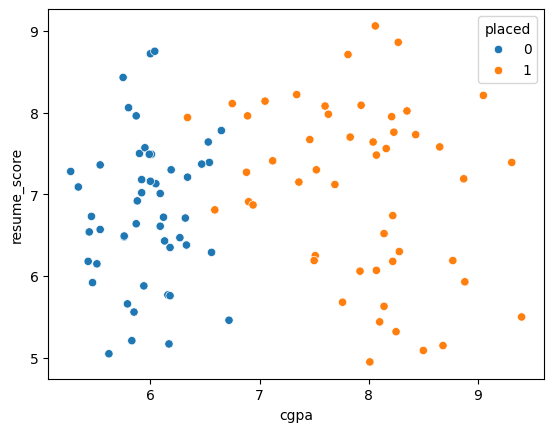

In [21]:
sns.scatterplot(data=df,x='cgpa',y='resume_score',hue='placed')

In [22]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('placed',axis=1),df['placed'],train_size=0.8)

In [23]:
x_train

,cgpa,resume_score
47,7.05,8.14
25,7.76,5.68
89,5.99,7.49
81,6.12,6.72
30,7.36,7.15
...,...,...
85,6.72,5.46
8,6.32,6.71
55,6.94,6.87
36,8.16,7.56


In [24]:
y_test

92    0
97    0
21    0
18    0
91    1
26    0
1     0
20    0
57    0
0     1
37    1
88    1
96    1
70    1
45    1
54    0
72    1
29    0
87    0
5     1
Name: placed, dtype: int64

In [25]:
y_train

47    1
25    1
89    0
81    0
30    1
     ..
85    0
8     0
55    1
36    1
4     1
Name: placed, Length: 80, dtype: int64

<Axes: xlabel='cgpa', ylabel='resume_score'>

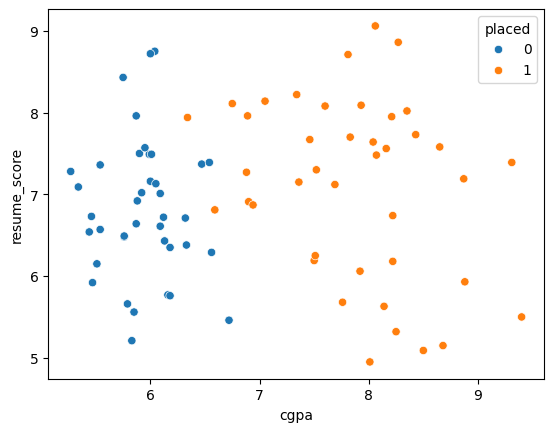

In [26]:
sns.scatterplot(x=x_train['cgpa'],y=x_train['resume_score'],hue=y_train)
plt.savefig('')

In [27]:
model=LinearRegression(n_jobs=-1)
model.fit(x_train,y_train)

LinearRegression(n_jobs=-1)

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


<Axes: >

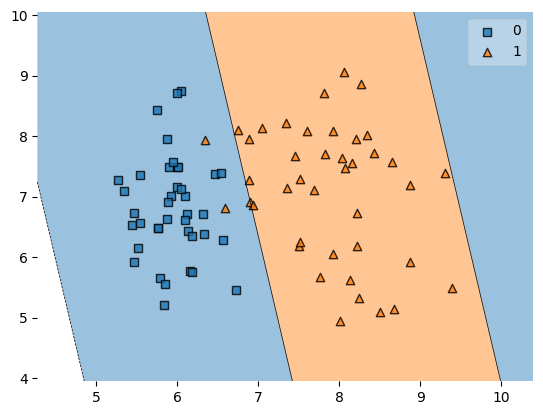

In [28]:
x=np.array(x_train)
y=np.array(y_train)
plot_decision_regions(x,y,model)

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


<Axes: >

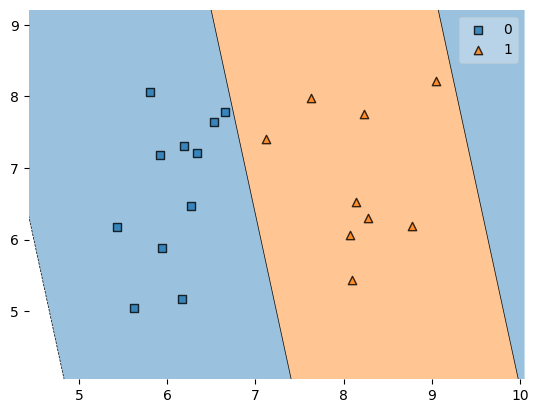

In [29]:
x=np.array(x_test)
y=np.array(y_test)
plot_decision_regions(x,y,model)

In [30]:
df 

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1
...,...,...,...
95,6.33,6.38,0
96,8.23,7.76,1
97,6.65,7.78,0
98,8.14,5.63,1


# Perceptron Trick 

# Introducing new column for bias term 

In [31]:
df 

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1
...,...,...,...
95,6.33,6.38,0
96,8.23,7.76,1
97,6.65,7.78,0
98,8.14,5.63,1


In [32]:
df['w0']=np.ones(df.shape[0])

In [33]:
df 

,cgpa,resume_score,placed,w0
0,8.14,6.52,1,1.0
1,6.17,5.17,0,1.0
2,8.27,8.86,1,1.0
3,6.88,7.27,1,1.0
4,7.52,7.30,1,1.0
...,...,...,...,...
95,6.33,6.38,0,1.0
96,8.23,7.76,1,1.0
97,6.65,7.78,0,1.0
98,8.14,5.63,1,1.0


In [34]:
# x_train,x_test,y_train,y_test=train_test_split(df.drop('placed',axis=1),df['placed'],train_size=0.8)

In [35]:
x=df.drop('placed',axis=1).values
x 

array([[8.14, 6.52, 1.  ],
       [6.17, 5.17, 1.  ],
       [8.27, 8.86, 1.  ],
       [6.88, 7.27, 1.  ],
       [7.52, 7.3 , 1.  ],
       [8.77, 6.19, 1.  ],
       [5.34, 7.09, 1.  ],
       [6.56, 6.29, 1.  ],
       [6.32, 6.71, 1.  ],
       [7.69, 7.12, 1.  ],
       [6.18, 6.35, 1.  ],
       [5.44, 6.54, 1.  ],
       [6.09, 7.01, 1.  ],
       [8.5 , 5.09, 1.  ],
       [7.51, 6.25, 1.  ],
       [8.88, 5.93, 1.  ],
       [8.04, 7.64, 1.  ],
       [7.81, 8.71, 1.  ],
       [5.94, 5.88, 1.  ],
       [6.75, 8.11, 1.  ],
       [5.8 , 8.06, 1.  ],
       [6.53, 7.64, 1.  ],
       [6.16, 5.77, 1.  ],
       [6.05, 7.13, 1.  ],
       [8.22, 6.18, 1.  ],
       [7.76, 5.68, 1.  ],
       [6.27, 6.47, 1.  ],
       [5.51, 6.15, 1.  ],
       [7.46, 7.67, 1.  ],
       [6.19, 7.3 , 1.  ],
       [7.36, 7.15, 1.  ],
       [5.92, 7.02, 1.  ],
       [5.87, 7.96, 1.  ],
       [8.43, 7.73, 1.  ],
       [8.87, 7.19, 1.  ],
       [8.07, 7.48, 1.  ],
       [8.16, 7.56, 1.  ],
 

In [36]:
y=df['placed'].values 
y 

array([1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0])

In [37]:
def perceptron(x,y,epochs): 
     weights=np.ones(x.shape[1])
     lr=0.1
     for epoch in range(epochs): 
         row=np.random.randint(0,len(x))
         y_hat=np.dot(x[row],weights)
         if y_hat >0: 
             y_hat=1 
         else: 
             y_hat=0 
      
         weights=weights+(lr*(y[row]-y_hat)*x[row]) 

     return weights 

In [38]:
w1,w2,w0=perceptron(x,y,200)
print('CGPA weight',w1)
print('resume score weight',w2)
print('bias term  weight',w0)

CGPA weight 2.427999999999999
resume score weight -2.250999999999999
bias term  weight 0.10000000000000014


In [39]:
df 

,cgpa,resume_score,placed,w0
0,8.14,6.52,1,1.0
1,6.17,5.17,0,1.0
2,8.27,8.86,1,1.0
3,6.88,7.27,1,1.0
4,7.52,7.30,1,1.0
...,...,...,...,...
95,6.33,6.38,0,1.0
96,8.23,7.76,1,1.0
97,6.65,7.78,0,1.0
98,8.14,5.63,1,1.0


In [40]:
output=6.17*w1+5.17*w2+w0
if output>=0.5: 
    print('Placed')
else: 
    print('Not Placed ')

Placed


In [41]:
m=-(w1/w2) 
c=-(w0/w2)

In [42]:
m 

np.float64(1.0786317192358952)

In [43]:
c 

np.float64(0.04442470013327418)

In [44]:
y_new=m*x+c 

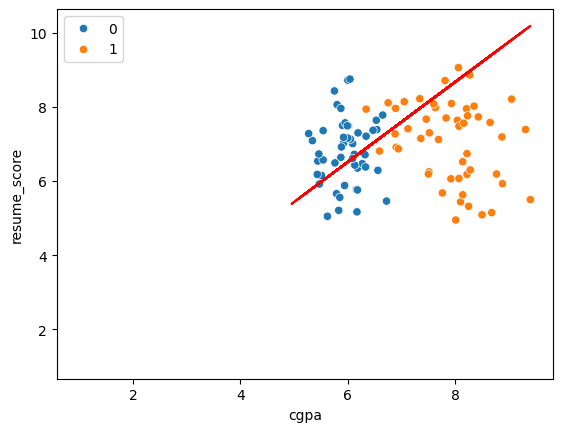

<Figure size 640x480 with 0 Axes>

In [45]:
plt.plot(x,y_new,color='red')
sns.scatterplot(data=df,x=df['cgpa'],y=df['resume_score'],hue=y)
plt.show()
plt.savefig('perceptron trick algorithm boundary.png')